Dataset link

https://www.kaggle.com/datasets/lokeshparab/amazon-products-dataset

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [2]:
df = pd.read_csv('../data/amazon_products/Air Conditioners.csv')

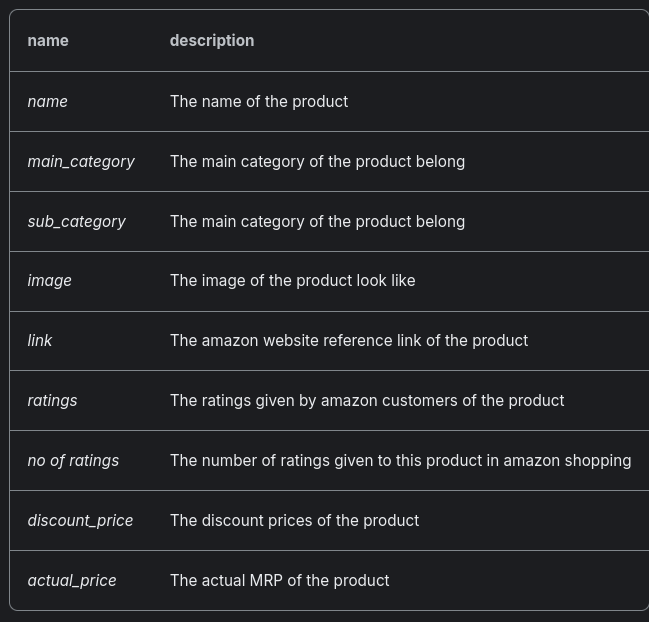

In [3]:
df.head()

,name,main_category,sub_category,image,link,ratings,no_of_ratings,discount_price,actual_price
0,Lloyd 1.5 Ton 3 Star Inverter Split Ac (5 In 1...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/31UISB90sY...,https://www.amazon.in/Lloyd-Inverter-Convertib...,4.2,"2,255","₹32,999","₹58,990"
1,LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (C...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/51JFb7FctD...,https://www.amazon.in/LG-Convertible-Anti-Viru...,4.2,"2,948","₹46,490","₹75,990"
2,LG 1 Ton 4 Star Ai Dual Inverter Split Ac (Cop...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/51JFb7FctD...,https://www.amazon.in/LG-Inverter-Convertible-...,4.2,"1,206","₹34,490","₹61,990"
3,LG 1.5 Ton 3 Star AI DUAL Inverter Split AC (C...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/51JFb7FctD...,https://www.amazon.in/LG-Convertible-Anti-Viru...,4.0,69,"₹37,990","₹68,990"
4,Carrier 1.5 Ton 3 Star Inverter Split AC (Copp...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/41lrtqXPiW...,https://www.amazon.in/Carrier-Inverter-Split-C...,4.1,630,"₹34,490","₹67,790"


### preproc.

In [4]:
df['ratings'] = pd.to_numeric(df['ratings'], errors='coerce')
df.no_of_ratings = df.no_of_ratings.str.replace(',','',regex=False).pipe(pd.to_numeric,errors='coerce')

In [5]:
df.discount_price = df.discount_price.str.replace('₹','',regex=False).str.replace(',','',regex=False).pipe(pd.to_numeric,errors='coerce')
df.actual_price = df.actual_price.str.replace('₹','',regex=False).str.replace(',','',regex=False).pipe(pd.to_numeric,errors='coerce')

In [6]:
df.head()

,name,main_category,sub_category,image,link,ratings,no_of_ratings,discount_price,actual_price
0,Lloyd 1.5 Ton 3 Star Inverter Split Ac (5 In 1...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/31UISB90sY...,https://www.amazon.in/Lloyd-Inverter-Convertib...,4.2,2255.0,32999.0,58990.0
1,LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (C...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/51JFb7FctD...,https://www.amazon.in/LG-Convertible-Anti-Viru...,4.2,2948.0,46490.0,75990.0
2,LG 1 Ton 4 Star Ai Dual Inverter Split Ac (Cop...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/51JFb7FctD...,https://www.amazon.in/LG-Inverter-Convertible-...,4.2,1206.0,34490.0,61990.0
3,LG 1.5 Ton 3 Star AI DUAL Inverter Split AC (C...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/51JFb7FctD...,https://www.amazon.in/LG-Convertible-Anti-Viru...,4.0,69.0,37990.0,68990.0
4,Carrier 1.5 Ton 3 Star Inverter Split AC (Copp...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/41lrtqXPiW...,https://www.amazon.in/Carrier-Inverter-Split-C...,4.1,630.0,34490.0,67790.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            720 non-null    object 
 1   main_category   720 non-null    object 
 2   sub_category    720 non-null    object 
 3   image           720 non-null    object 
 4   link            720 non-null    object 
 5   ratings         423 non-null    float64
 6   no_of_ratings   423 non-null    float64
 7   discount_price  457 non-null    float64
 8   actual_price    500 non-null    float64
dtypes: float64(4), object(5)
memory usage: 50.8+ KB


### avg usd for 2023 82.57849999999999

In [8]:
df['discount_price_usd']=(df['discount_price']/82.57849999999999).round(2)
df['actual_price_usd']=(df['actual_price']/82.57849999999999).round(2)
df.head()

,name,main_category,sub_category,image,link,ratings,no_of_ratings,discount_price,actual_price,discount_price_usd,actual_price_usd
0,Lloyd 1.5 Ton 3 Star Inverter Split Ac (5 In 1...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/31UISB90sY...,https://www.amazon.in/Lloyd-Inverter-Convertib...,4.2,2255.0,32999.0,58990.0,399.61,714.35
1,LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (C...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/51JFb7FctD...,https://www.amazon.in/LG-Convertible-Anti-Viru...,4.2,2948.0,46490.0,75990.0,562.98,920.22
2,LG 1 Ton 4 Star Ai Dual Inverter Split Ac (Cop...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/51JFb7FctD...,https://www.amazon.in/LG-Inverter-Convertible-...,4.2,1206.0,34490.0,61990.0,417.66,750.68
3,LG 1.5 Ton 3 Star AI DUAL Inverter Split AC (C...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/51JFb7FctD...,https://www.amazon.in/LG-Convertible-Anti-Viru...,4.0,69.0,37990.0,68990.0,460.05,835.45
4,Carrier 1.5 Ton 3 Star Inverter Split AC (Copp...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/41lrtqXPiW...,https://www.amazon.in/Carrier-Inverter-Split-C...,4.1,630.0,34490.0,67790.0,417.66,820.92


In [9]:
df[['sub_category','main_category']].describe()

,sub_category,main_category
count,720,720
unique,1,1
top,Air Conditioners,appliances
freq,720,720


useless categories, without other datasets

In [10]:
df=df.drop(columns=(['sub_category','main_category']))

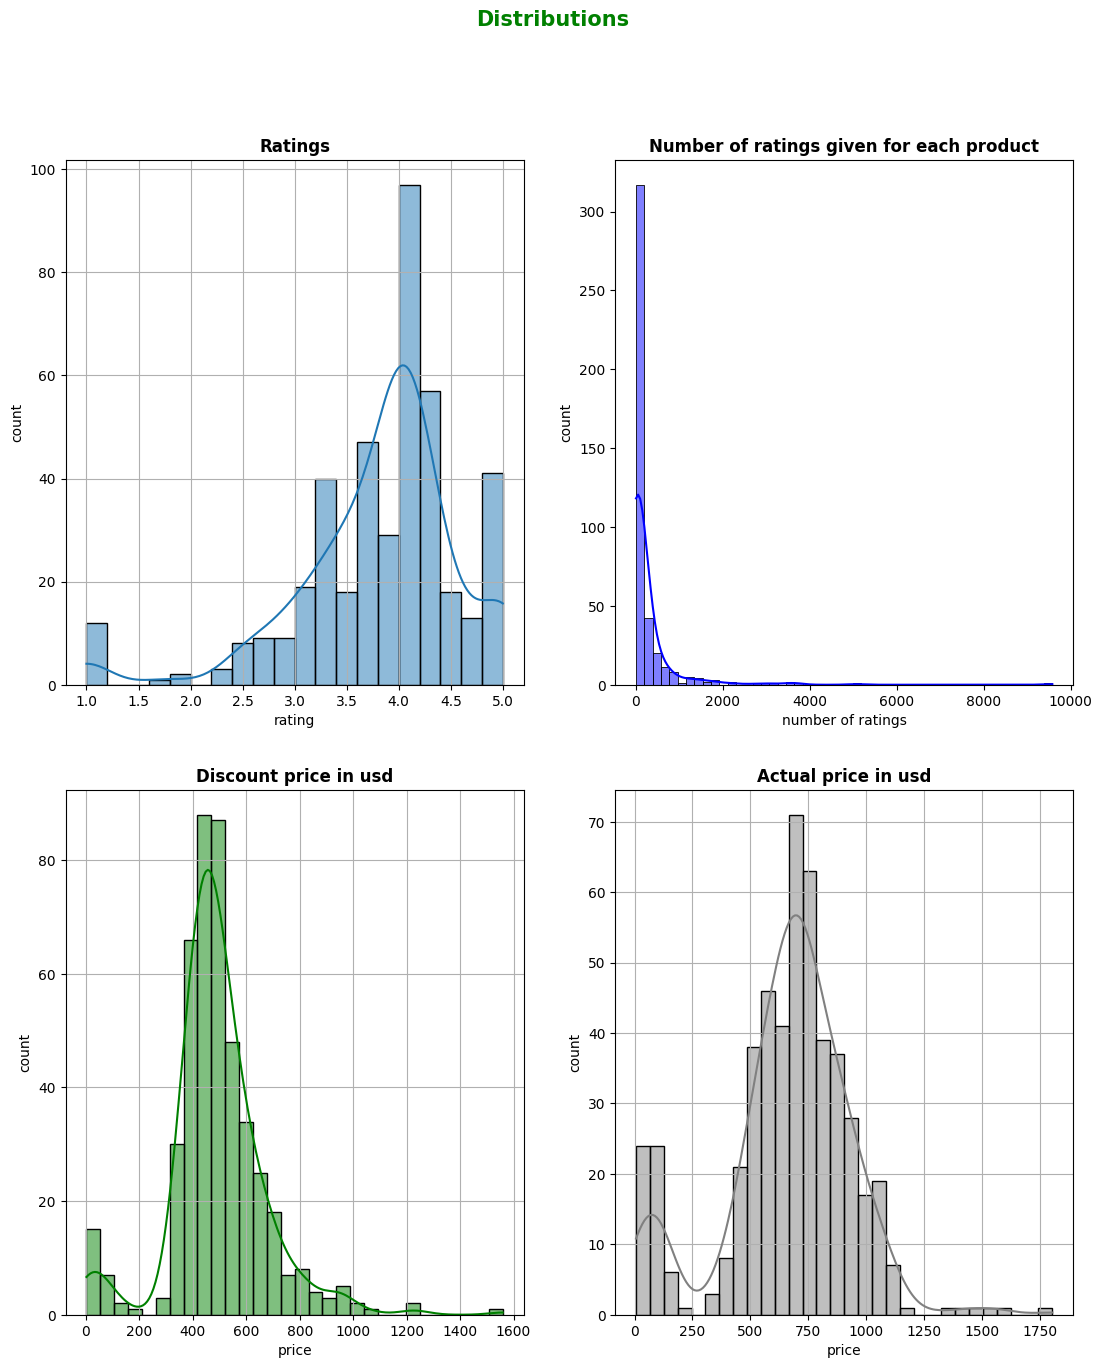

In [11]:
plt.figure(figsize=(13,15))
plt.suptitle('Distributions', fontweight='bold', fontsize=15, color='green')

plt.subplot(2,2,1)
sns.histplot(df['ratings'], bins=20, kde=True)
plt.title('Ratings', fontweight='bold')
plt.grid(True)
plt.xlabel('rating')
plt.ylabel('count')

plt.subplot(2,2,2)
sns.histplot(df['no_of_ratings'],bins=50, kde=True, color='blue')
plt.title('Number of ratings given for each product', fontweight='bold')
plt.xlabel('number of ratings')
plt.ylabel('count')

plt.subplot(2,2,3)
sns.histplot(df['discount_price_usd'],bins=30, kde=True, color='green')
plt.title('Discount price in usd', fontweight='bold')
plt.grid(True)
plt.xlabel('price')
plt.ylabel('count')

plt.subplot(2,2,4)
sns.histplot(df['actual_price_usd'],bins=30, kde=True, color='gray')
plt.title('Actual price in usd', fontweight='bold')
plt.grid(True)
plt.xlabel('price')
plt.ylabel('count')

plt.show();

In [12]:
numerator = ((df['no_of_ratings']-df['no_of_ratings'].mean()))**2
denominator = ((df['no_of_ratings']-df['no_of_ratings'].mean())**2).sum()
leverage_stats = 1/423 + (numerator/denominator)
threshold = 2/423
high_leverage = leverage_stats[leverage_stats > threshold]
high_leverage_count = (leverage_stats > threshold).sum()
low_leverage_count = (leverage_stats <= threshold).sum()

            Extremity of the numbers of ratings                 

Bottom of the leverage: 0.00139 
Minimum value in the list: 0.00236 
Threshold: 0.00473 
Number of high leverage values: 25


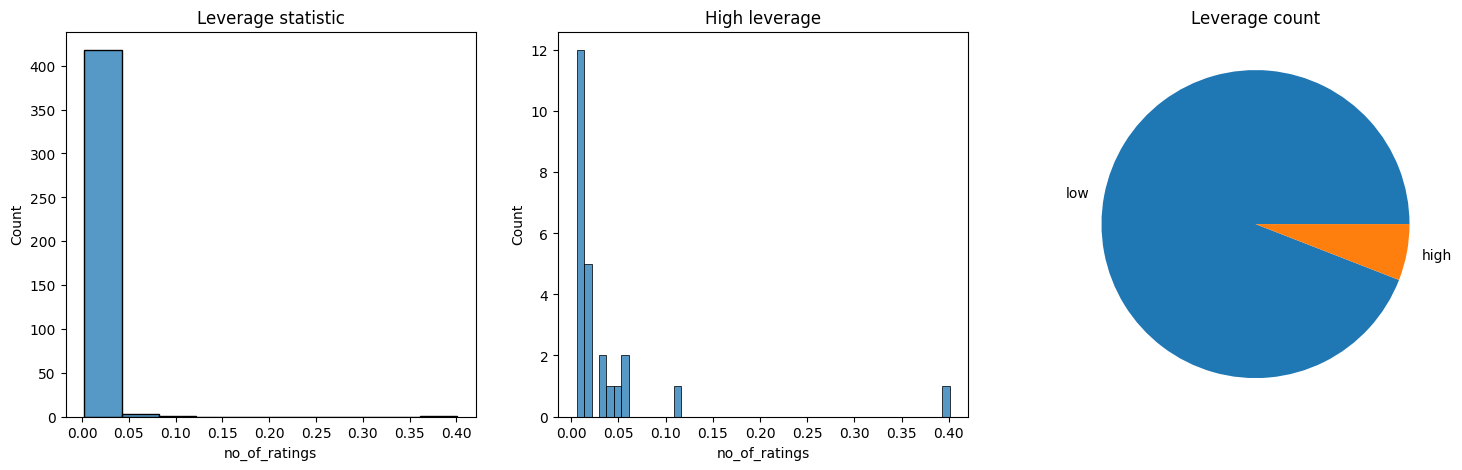

In [13]:
print('\033[42m            Extremity of the numbers of ratings                 \033[0m\n')
print(f"Bottom of the leverage: {(1/len(df['no_of_ratings'])):.5f} \nMinimum value in the list: {leverage_stats.min():.5f} \nThreshold: {threshold:.5f} \nNumber of high leverage values: {high_leverage.size}")
plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
sns.histplot(leverage_stats, bins=10)
plt.title('Leverage statistic')
plt.subplot(1,3,2)
sns.histplot(high_leverage, bins=50)
plt.title('High leverage')
plt.subplot(1,3,3)
plt.pie([low_leverage_count, high_leverage_count],labels=['low','high'])
plt.title('Leverage count')
plt.show();

### outliers

In [14]:
# iqr no_of_ratings ratings
# discount/actual price

q1_no = df.no_of_ratings.quantile(0.25)
q3_no = df.no_of_ratings.quantile(0.75)
iqr_no = q3_no-q1_no
lower_no=q1_no-1.5*iqr_no
upper_no=q3_no+1.5*iqr_no
clean_no = (df['no_of_ratings'] >= lower_no) & (df['no_of_ratings'] <= upper_no)
valid_no = df['no_of_ratings'].notna()

q1_ra = df.ratings.quantile(0.25)
q3_ra = df.ratings.quantile(0.75)
iqr_ra = q3_ra-q1_ra
lower_ra=q1_ra-1.5*iqr_ra
upper_ra=q3_ra+1.5*iqr_ra
clean_ra = (df['ratings'] >= lower_ra) & (df['ratings'] <= upper_ra)
valid_ra = df['ratings'].notna()

zscr_disc = stats.zscore(df.discount_price_usd, nan_policy='omit')
clean_disc = (zscr_disc < 3) & (zscr_disc > -3)
valid_disc = ~np.isnan(zscr_disc)

zscr_actu = stats.zscore(df.actual_price_usd, nan_policy='omit')
clean_actu = (zscr_actu < 3) & (zscr_actu > -3)
valid_actu = ~np.isnan(zscr_actu)

print('\033[42m             Outliers                 \033[0m\n')
outlier_dict = {
    'number of ratings': (valid_no, clean_no),
    'ratings': (valid_ra, clean_ra),
    'discount price': (valid_disc, clean_disc),
    'actual price': (valid_actu, clean_actu)
}
for k,(i,j) in outlier_dict.items():
    n_valid = i.sum()
    n_out = n_valid - (j & i).sum()
    print(f"Number of outliers in {k:20s}: {n_out:3d} / {n_valid}")

             Outliers                 

Number of outliers in number of ratings   :  53 / 423
Number of outliers in ratings             :  18 / 423
Number of outliers in discount price      :   4 / 457
Number of outliers in actual price        :   3 / 500


In [15]:
final_mask = (
    (clean_no   | ~valid_no) &
    (clean_ra   | ~valid_ra) &
    (clean_disc | ~valid_disc) &
    (clean_actu | ~valid_actu)
)

df_out_less = df[final_mask]

In [16]:
df_out_less.info()

<class 'pandas.core.frame.DataFrame'>
Index: 644 entries, 3 to 719
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                644 non-null    object 
 1   image               644 non-null    object 
 2   link                644 non-null    object 
 3   ratings             350 non-null    float64
 4   no_of_ratings       350 non-null    float64
 5   discount_price      395 non-null    float64
 6   actual_price        434 non-null    float64
 7   discount_price_usd  395 non-null    float64
 8   actual_price_usd    434 non-null    float64
dtypes: float64(6), object(3)
memory usage: 50.3+ KB


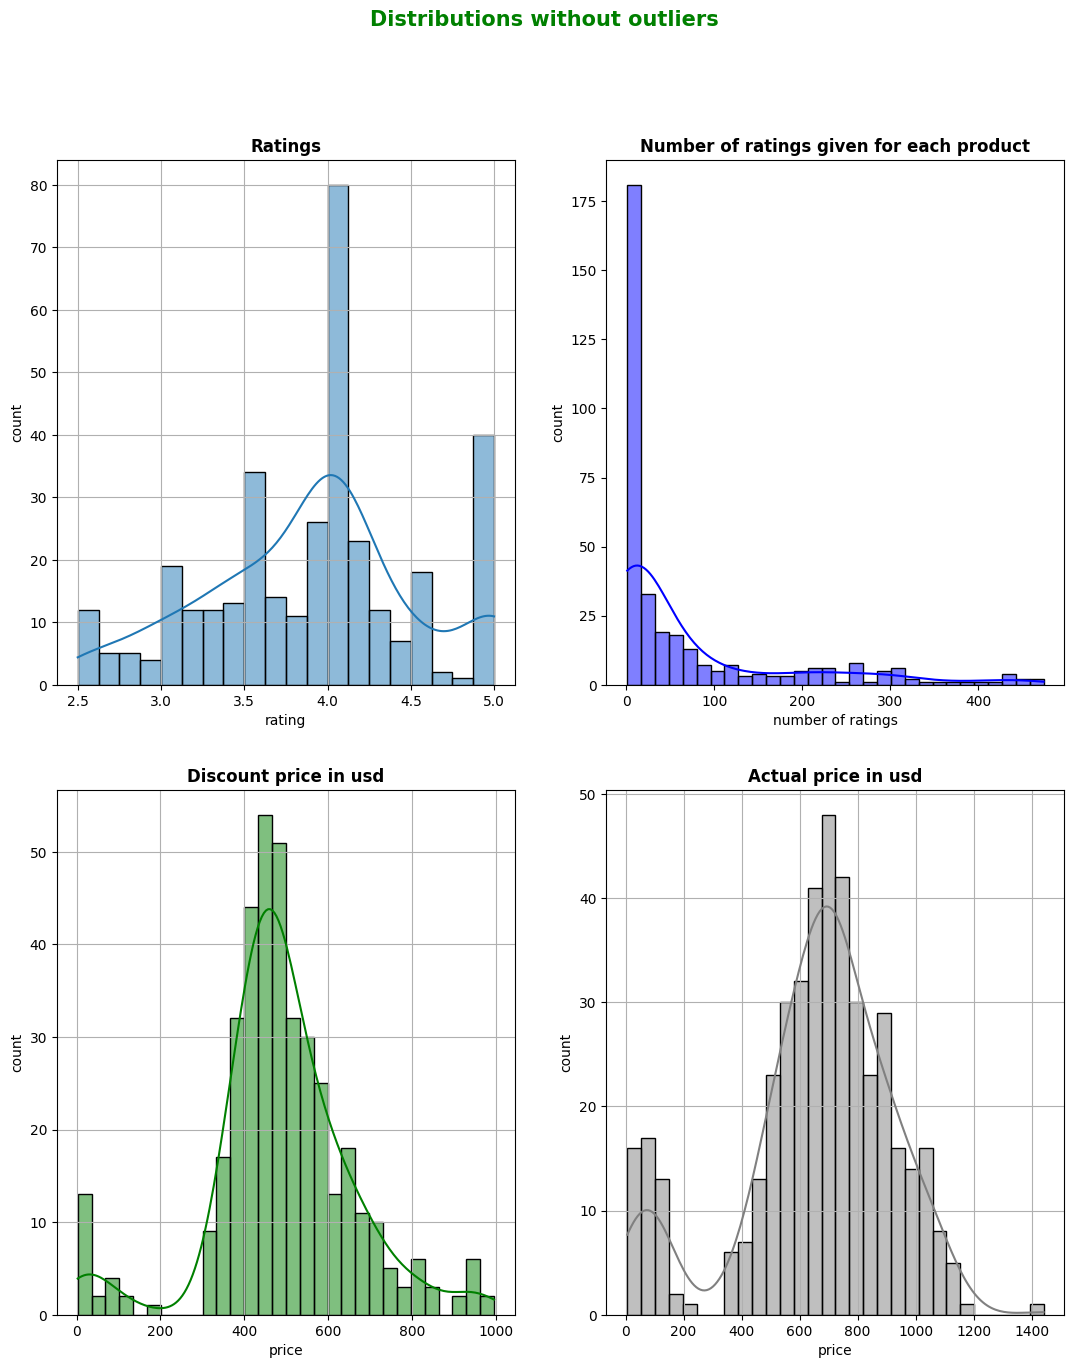

In [17]:
plt.figure(figsize=(13,15))
plt.suptitle('Distributions without outliers', fontweight='bold', fontsize=15, color='green')

plt.subplot(2,2,1)
sns.histplot(df_out_less['ratings'], bins=20, kde=True)
plt.title('Ratings', fontweight='bold')
plt.grid(True)
plt.xlabel('rating')
plt.ylabel('count')

plt.subplot(2,2,2)
sns.histplot(df_out_less['no_of_ratings'],bins=30, kde=True, color='blue')
plt.title('Number of ratings given for each product', fontweight='bold')
plt.xlabel('number of ratings')
plt.ylabel('count')

plt.subplot(2,2,3)
sns.histplot(df_out_less['discount_price_usd'],bins=30, kde=True, color='green')
plt.title('Discount price in usd', fontweight='bold')
plt.grid(True)
plt.xlabel('price')
plt.ylabel('count')

plt.subplot(2,2,4)
sns.histplot(df_out_less['actual_price_usd'],bins=30, kde=True, color='gray')
plt.title('Actual price in usd', fontweight='bold')
plt.grid(True)
plt.xlabel('price')
plt.ylabel('count')

plt.show();

### Correlation

In [18]:
print('\033[42m             Correlation                 \033[0m\n')
print(f"\033[1mDiscount price:\033[0m\n{df[['discount_price','ratings','no_of_ratings']].corr()}\n")
print(f"\033[1mActual price:\033[0m\n{df[['actual_price_usd','ratings','no_of_ratings']].corr()}")

             Correlation                 

Discount price:
                discount_price   ratings  no_of_ratings
discount_price        1.000000  0.021672      -0.107345
ratings               0.021672  1.000000       0.091584
no_of_ratings        -0.107345  0.091584       1.000000

Actual price:
                  actual_price_usd   ratings  no_of_ratings
actual_price_usd          1.000000  0.248649      -0.060189
ratings                   0.248649  1.000000       0.091584
no_of_ratings            -0.060189  0.091584       1.000000


- Relationship between prices and ratings are not significant

In [19]:
def categorize_ratings(rating):
    if rating <=1:
        return 1
    elif 1<rating<=2:
        return 2
    elif 2<rating<=3:
        return 3
    elif 3<rating<=4:
        return 4
    elif 4<rating<=5:
        return 5
df['cat_ratings'] = df['ratings'].apply(categorize_ratings)

def categorize_act_price(price):
    if price<450:
        return 'budget'
    elif 450<=price<600:
        return 'mid_range'
    elif 600<=price:
        return 'high_end'
df['cat_act_price'] = df['actual_price_usd'].apply(categorize_act_price)

- Reminder. Ratings are biased.
 There is a chance that the most of the ratings given to the products in general are either customer dissatisfaction with the product/company or the opposite, over-satisfaction.
- Budget and Ratings.
 Air conditioners in low budget have a wider range of the ratings.
 Based on only this information, follow to the conclusion that, for low budget, there is a possibility of receiving both good qualiity air conditioner and bad bad quality(defectivity, unreliability)
- Compilation of top products is meaningless, because of the absense of the number of sales.
 The number of product ratings can possibly be a replacement, assuming that there is linear realtionship between the number of ratings and sales.


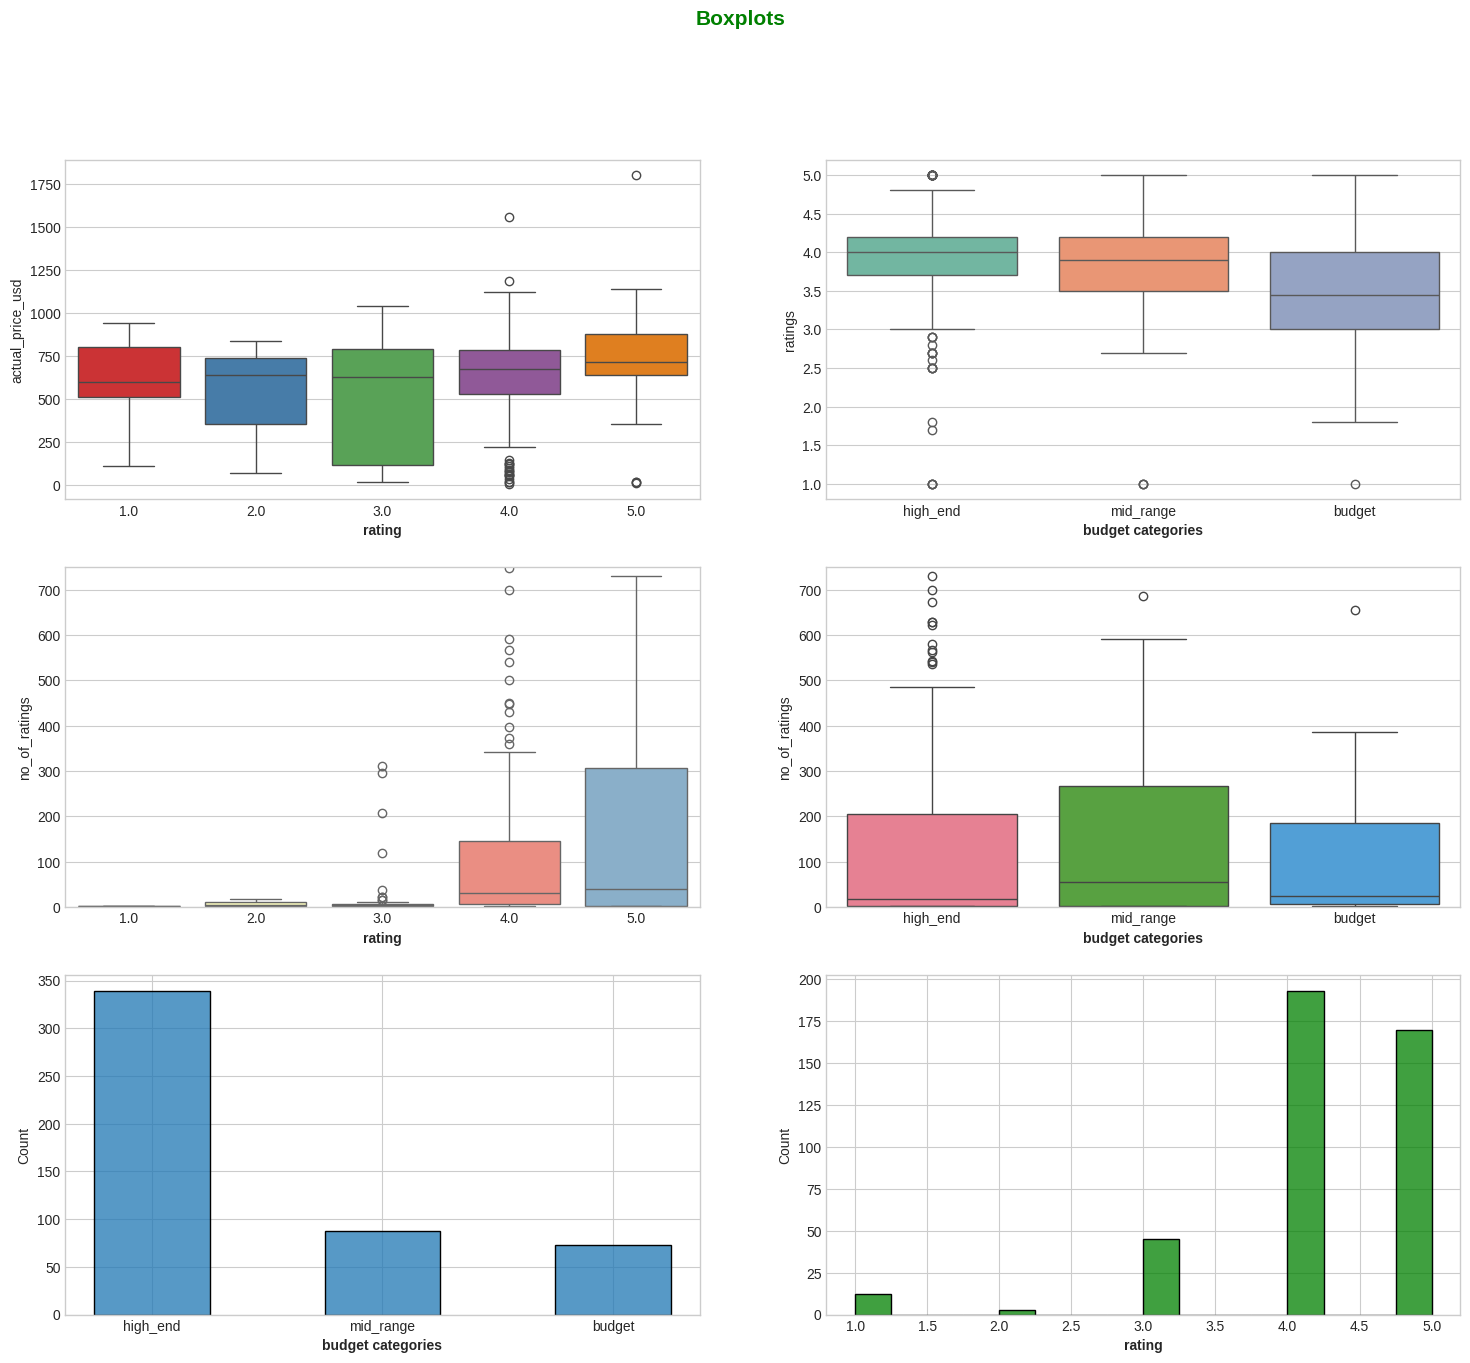

In [20]:
print('- Reminder. Ratings are biased.\n There is a chance that the most of the ratings given to the products in general are either customer dissatisfaction with the product/company or the opposite, over-satisfaction.')
print('- Budget and Ratings.\n Air conditioners in low budget have a wider range of the ratings.\n Based on only this information, follow to the conclusion that, for low budget, there is a possibility of receiving both good qualiity air conditioner and bad bad quality(defectivity, unreliability)')
print('- Compilation of top products is meaningless, because of the absense of the number of sales.\n The number of product ratings can possibly be a replacement, assuming that there is linear realtionship between the number of ratings and sales.')
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(18,15))
plt.suptitle('Boxplots', fontsize=15, fontweight='bold', color='green')

plt.subplot(3,2,1)
sns.boxplot(data=df, x='cat_ratings',y='actual_price_usd', palette='Set1', hue='cat_ratings', legend=False)
plt.xlabel('rating',fontweight='bold')

plt.subplot(3,2,2)
sns.boxplot(data=df, x='cat_act_price',y='ratings', palette='Set2', hue='cat_act_price', legend=False)
plt.xlabel('budget categories',fontweight='bold')

plt.subplot(3,2,3)
sns.boxplot(data=df, x='cat_ratings',y='no_of_ratings', palette='Set3', hue='cat_ratings', legend=False)
plt.xlabel('rating',fontweight='bold')
plt.ylim(0,750)

plt.subplot(3,2,4)
sns.boxplot(data=df, x='cat_act_price',y='no_of_ratings', palette='husl', hue='cat_act_price', legend=False)
plt.xlabel('budget categories',fontweight='bold')
plt.ylim(0,750)

plt.subplot(3,2,5)
sns.histplot(df['cat_act_price'], shrink=0.5)
plt.xlabel('budget categories',fontweight='bold')

plt.subplot(3,2,6)
sns.histplot(df['cat_ratings'], color='green')
plt.xlabel('rating',fontweight='bold')

plt.show();